In [ ]:
House price Prediction

Introduction:
This project analyses data from a 1990 California census
Our main objectives are:
1.Exploratory Analysis
2.Apply a machine learning model

In [ ]:
Step 1:
Import all necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
data = pd.read_csv("housing.csv")

To get an overview of the dataset:

In [4]:
data#note the ocean_proximity column,those string values can not be pluged into a model

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


The median_house_value column is our target feature(our goal is to predict housing price) all other attributes will serve as input feature and will be used
to predict the target feature.
At an initial look the column, ocean_proximity stands out, it has text values and these will need to be pre-processed before being plugged into a model.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


The above summary illustrates that most columns, say for total_bedrooms have 20640 non-null values.

In [6]:
print(data.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


total_bedrooms in constrast has 207 values missing, to resolve this we apply 'dropna()', which will return a dataframe with only non-null values

In [7]:
data.dropna(inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


We will now apply a train test split:
This splits our data into to sets, one to test the model and another to evaluate the model.This is done to see how well the odel responds on unseen data

In [9]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

x represents the data without the target feature and y represents the data with only the target feature

In [10]:
x

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [11]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

The test data we are declaring below will not be touched until it comes time to evaluate the model.

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

To observe basic correlations we shall join the x and y train data sets

In [13]:
train_data = x_train.join(y_train)

In [14]:
train_data 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18942,-122.08,38.30,2.0,6718.0,858.0,2012.0,654.0,6.8872,INLAND,305200.0
9715,-121.67,36.68,38.0,5561.0,1292.0,3523.0,1253.0,2.8289,<1H OCEAN,168300.0
9823,-121.92,36.62,52.0,728.0,161.0,313.0,142.0,3.4327,NEAR OCEAN,254500.0
5988,-117.72,34.10,32.0,3241.0,895.0,1592.0,810.0,2.4952,INLAND,181800.0
4579,-118.28,34.07,25.0,7522.0,3179.0,7221.0,2902.0,2.0173,<1H OCEAN,177500.0
...,...,...,...,...,...,...,...,...,...,...
7845,-118.18,33.90,34.0,1248.0,320.0,1960.0,338.0,3.1012,<1H OCEAN,140400.0
4064,-118.46,34.16,16.0,4590.0,1200.0,2195.0,1139.0,3.8273,<1H OCEAN,334900.0
3143,-118.16,35.05,44.0,1297.0,307.0,776.0,278.0,2.5875,INLAND,68900.0
12453,-114.57,33.52,27.0,173.0,35.0,117.0,34.0,2.0833,INLAND,45000.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

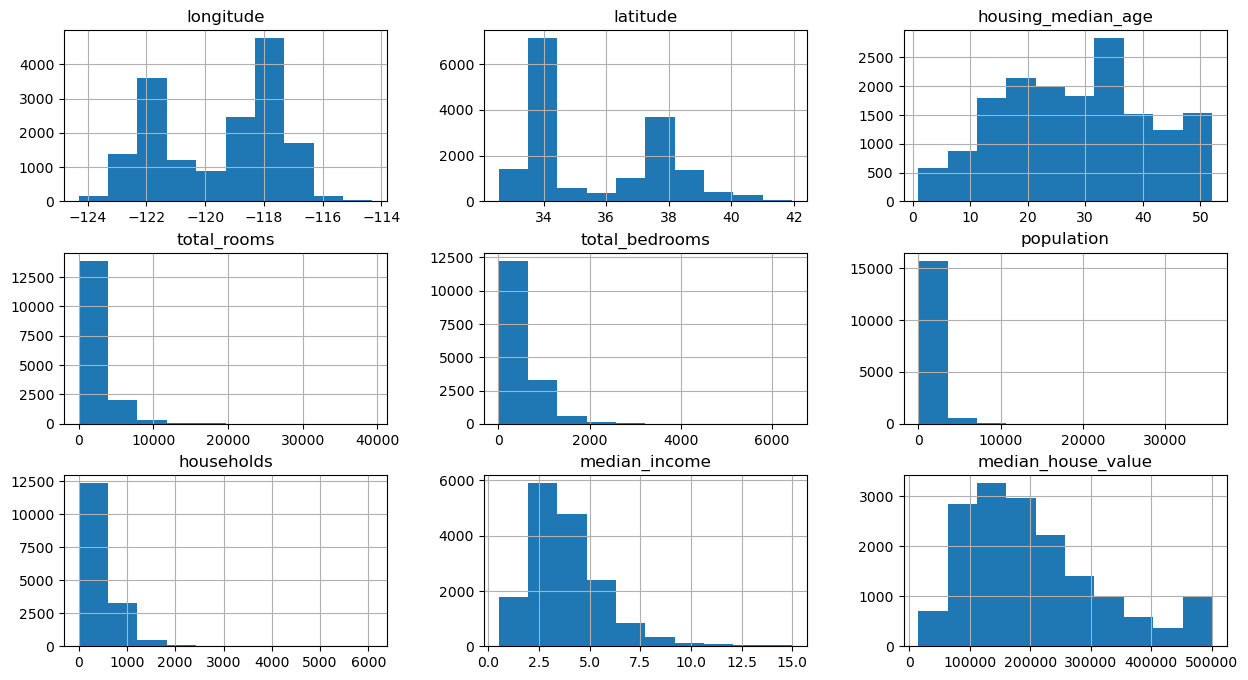

In [15]:
train_data.hist(figsize=(15,8))

The columns:total_rooms, total_bedrooms, population, and households are negatively skewed.
To resolve this:

In [16]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

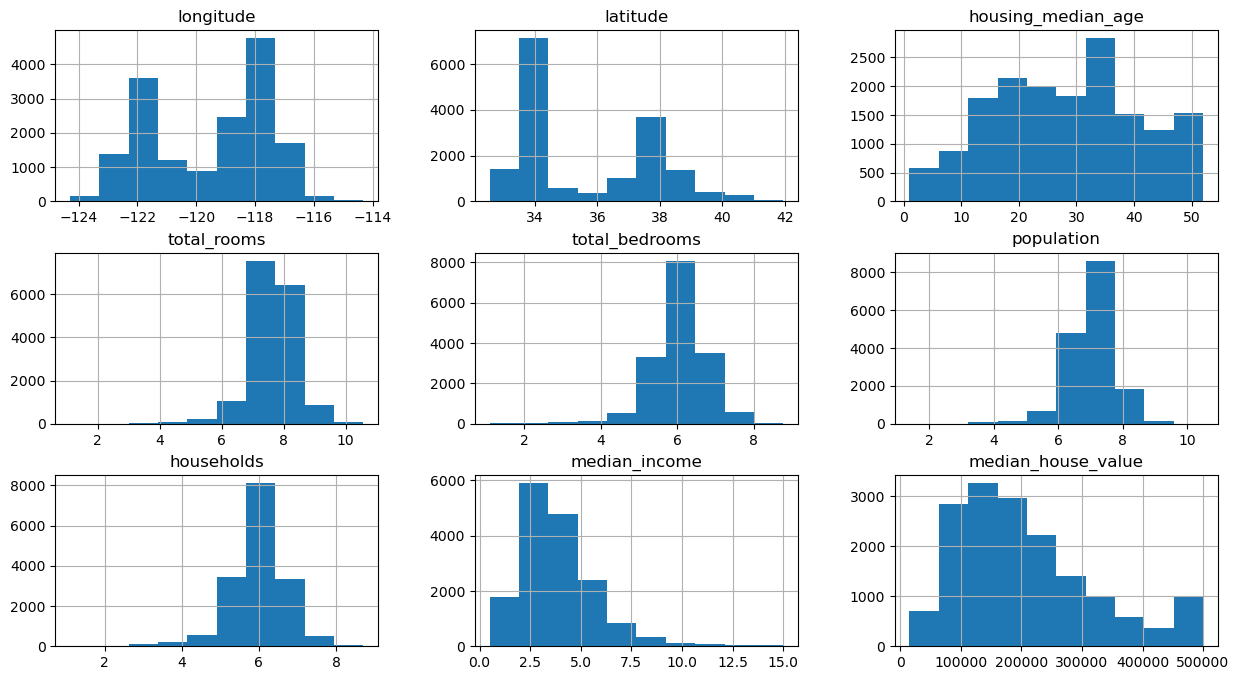

In [17]:
train_data.hist(figsize=(15,8))

Now all the graphs have a bell curve shape

<Axes: >

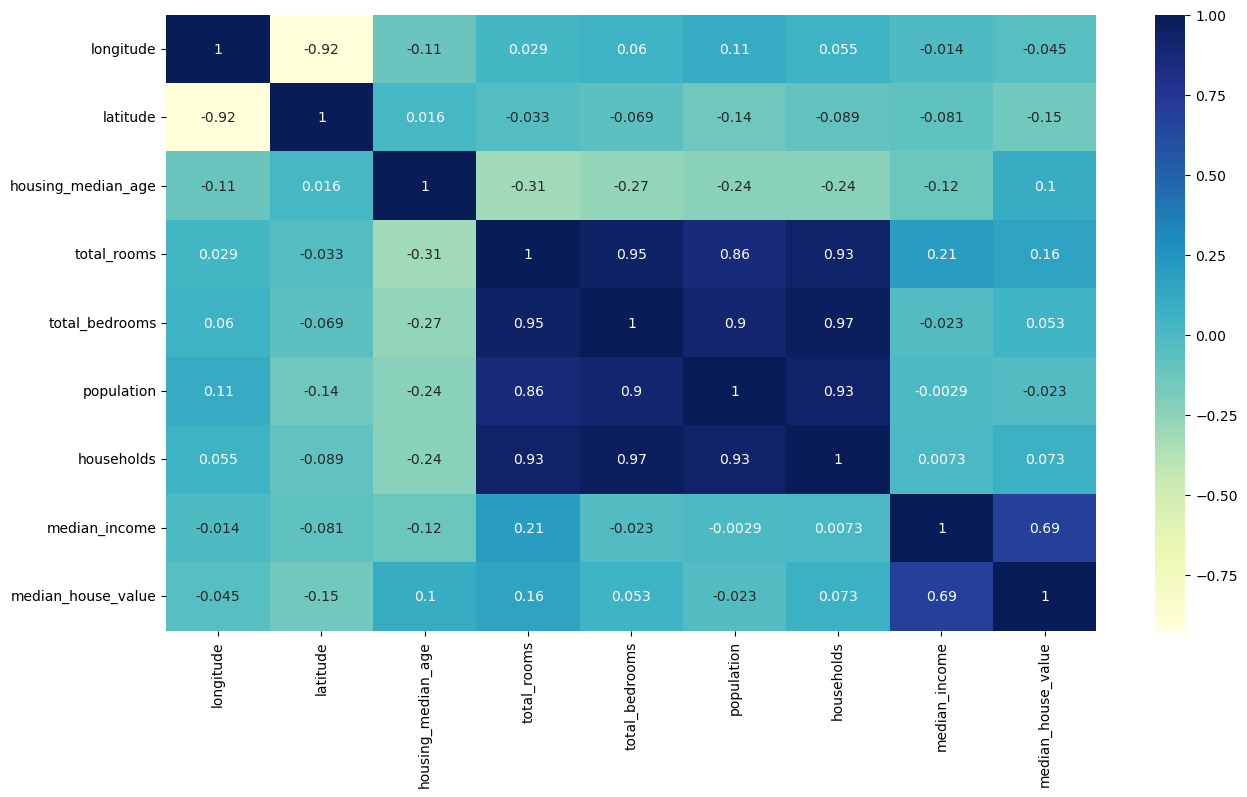

In [18]:

plt.figure(figsize=(15,8)) 
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu')

Earlier we had noted the column:ocean_proximity, it stood out because it was a categorical column and what we said earlier remains true, those values can not be put in a model,we shall now resolve that.
To do this we can not simply attach an integer values to any one categorical value(ordinal encode), we must instead turn the categorical values into binary features.

To further explore this let us exam ocean proximity:

In [19]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7221
INLAND        5203
NEAR OCEAN    2102
NEAR BAY      1818
ISLAND           2
Name: count, dtype: int64

We shall create a new feature for each category and assign it to a binary value, then we shall drop the oxean proximity column and jon these new features to the rest of the training dataset.

In [20]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)

In [21]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
18942,-122.08,38.30,2.0,8.812695,6.755769,7.607381,6.484635,6.8872,305200.0,0,1,0,0,0
9715,-121.67,36.68,38.0,8.623713,7.164720,8.167352,7.134094,2.8289,168300.0,1,0,0,0,0
9823,-121.92,36.62,52.0,6.591674,5.087596,5.749393,4.962845,3.4327,254500.0,0,0,0,0,1
5988,-117.72,34.10,32.0,8.083946,6.797940,7.373374,6.698268,2.4952,181800.0,0,1,0,0,0
4579,-118.28,34.07,25.0,8.925720,8.064636,8.884887,7.973500,2.0173,177500.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7845,-118.18,33.90,34.0,7.130099,5.771441,7.581210,5.826000,3.1012,140400.0,1,0,0,0,0
4064,-118.46,34.16,16.0,8.431853,7.090910,7.694393,7.038784,3.8273,334900.0,1,0,0,0,0
3143,-118.16,35.05,44.0,7.168580,5.730100,6.655440,5.631212,2.5875,68900.0,0,1,0,0,0
12453,-114.57,33.52,27.0,5.159055,3.583519,4.770685,3.555348,2.0833,45000.0,0,1,0,0,0


<Axes: >

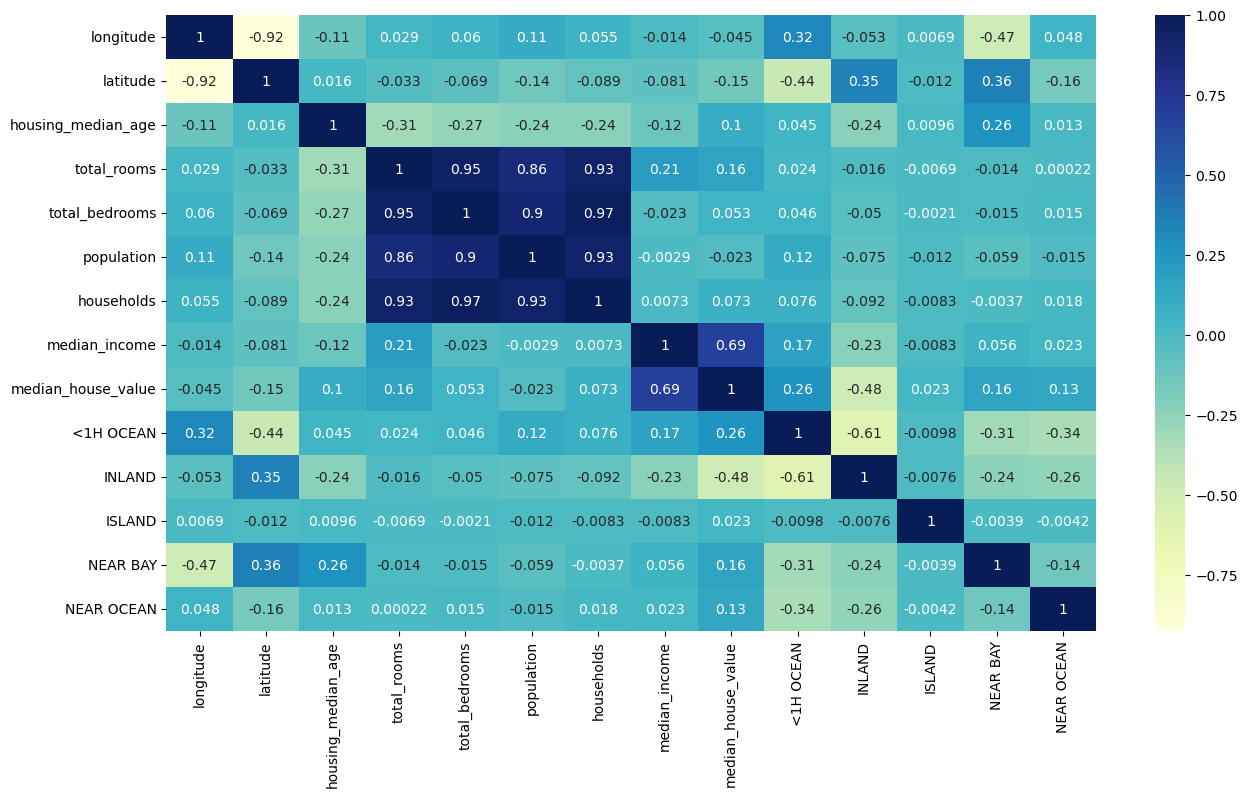

In [22]:
plt.figure(figsize=(15,8)) 
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu')

In doing this we come to more insightful analysis, for example we can now infer that being less than an hour from the ocean has more postive correlation to median_house_value 
when compared to the other 'ocean proximity features'
This is further exemplified by the scatter plot below-it compares latitude and longitude with respect to the median house value

<Axes: xlabel='latitude', ylabel='longitude'>

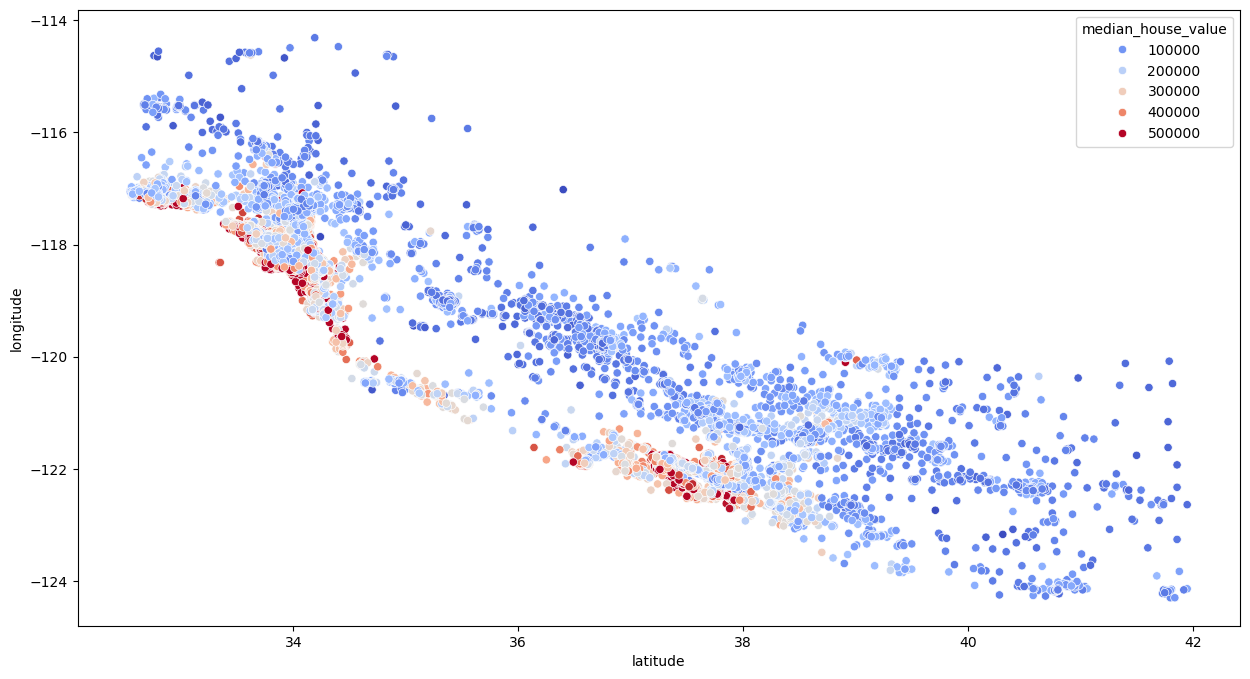

In [23]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

Step 2:Feature Engineering
Features that might be interesting is seeing the ratio of rooms to bedrooms(how many rooms are bedrooms) and the ratio of households to rooms(how amny rooms are in households)

In [24]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

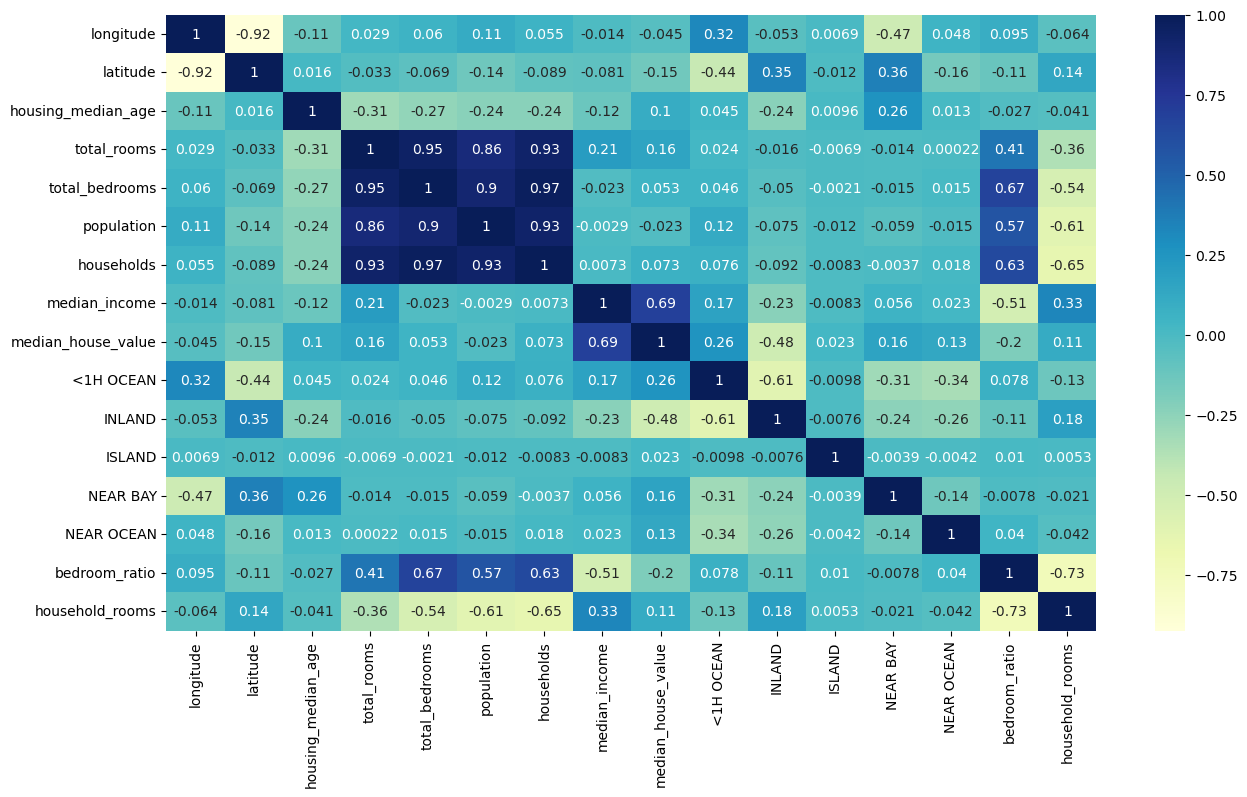

In [25]:
plt.figure(figsize=(15,8)) 
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu')

We had split our data earlier into  train and test(albeit too early), though we dont have to to the train_test_split all the changes we have made to the data hence since must be 
applied to the test data
We must first separate the x and y data

In [28]:
from sklearn.linear_model import LinearRegression

x_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg = LinearRegression()

reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The data above is not yet scaled but regardless let us evaluate how it performs when aapplied to the regression model
After spiltting x and y we can then apply all changes exhibited by the train data onto the test data

In [30]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity, dtype=int)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']


In [32]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [33]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
5300,-118.45,34.07,19.0,8.485909,7.383989,8.230044,7.339538,1.5830,350000.0,1,0,0,0,0,0.870147,1.156191
18603,-122.08,37.15,23.0,6.228511,4.574711,5.579730,4.499810,7.1366,273900.0,0,0,0,0,1,0.734479,1.384172
14037,-117.14,32.75,25.0,7.554335,6.242223,6.863803,6.148468,2.4828,133300.0,0,0,0,0,1,0.826310,1.228653
19567,-120.97,37.61,16.0,7.190676,5.929589,6.785588,5.929589,1.8710,103900.0,0,1,0,0,0,0.824622,1.212677
11008,-117.78,33.78,6.0,9.189423,7.157735,8.228177,7.073270,10.1714,481500.0,1,0,0,0,0,0.778910,1.299176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20407,-118.88,34.20,23.0,8.489411,6.393591,7.569928,6.388561,7.3409,316000.0,1,0,0,0,0,0.753125,1.328845
10205,-117.93,33.88,45.0,7.175490,5.683580,6.373320,5.564520,4.0812,241700.0,1,0,0,0,0,0.792082,1.289507
7995,-118.15,33.85,36.0,7.307873,5.560682,6.551080,5.587249,4.0781,217300.0,1,0,0,0,0,0.760917,1.307956
73,-122.29,37.81,46.0,2.564949,1.609438,2.944439,2.079442,0.4999,67500.0,0,0,0,1,0,0.627474,1.233480


In [34]:
reg.score(x_test,y_test)

0.6662197860913266

Random Forest Model:A more pwerful model


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)#you usually dont have to do this fot the output(y)

forest = RandomForestRegressor()

forest.fit(x_train_s,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
x_test_s = scaler.fit_transform(x_test)
forest.score(x_test_s,y_test)

0.7851757829637951

We are now going to use grid search with cross validation:
we are going to split the data into k-folds and we will use all but one fold to train the data and the last to evaluate it.
if we had 10 folds we would train with 9 and the evaluate with the last

In [ ]:
from sklearn.model_selection import GridSearchCV
#we shall specify hyper parameters 
param_grid = {  
       "n_estimators":[100, 200, 300],
       "min_samples_split":[2, 4],
       "max_depth":[None, 4, 8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True)
grid_search.fit(x_train_s, y_train)

In [ ]:
print(grid_search.best_estimator_)

In [ ]:
print(grid_search.best_estimator_.score(x_test_s, y_test))